# Load libraries and set device up

In [ ]:
import importlib
import libraries.graph as clg

try:
    cld = importlib.reload(cld)
except NameError:
    pass

try:
    clg = importlib.reload(clg)
except NameError:
    pass

In [ ]:
import numpy as np
import torch.nn as nn
import os
import torch
from pathlib import Path
import importlib

import libraries.model as clm
import libraries.dataset as cld
import libraries.graph as clg

cld = importlib.reload(cld)
clg = importlib.reload(clg)

from torch_geometric.loader import DataLoader

# Checking if pytorch can run in GPU, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [20]:
import os
print(os.getcwd())

c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science


In [21]:
workspace_root = Path.cwd()
while not (workspace_root / 'input' / 'candidates').exists() and workspace_root.parent != workspace_root:
    workspace_root = workspace_root.parent

print(f"Using repository root: {workspace_root}")

folder = 'free-energies'

target_folder = workspace_root / f'models/{folder}'
data_root = workspace_root / 'input' / 'candidates'

Using repository root: c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science


In [22]:
from datetime import datetime

# Create timestamped folder for this model run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
timestamped_folder = f'{target_folder}/results_{timestamp}'
os.makedirs(timestamped_folder, exist_ok=True)

print(f'Model results will be saved to: {timestamped_folder}')

Model results will be saved to: c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\models\free-energies/results_20260427_171527


In [23]:
files_names = {
    # Reusable files (common for all models)
    'dataset':              f'{target_folder}/dataset.pt',
    'std_parameters':       f'{target_folder}/standardized_parameters.json',
    'dataset_parameters':   f'{target_folder}/dataset_parameters.json',
    
    # Model-specific files (unique per model run)
    'train_dataset_std':    f'{timestamped_folder}/train_dataset_std.pt',
    'val_dataset_std':      f'{timestamped_folder}/val_dataset_std.pt',
    'test_dataset_std':     f'{timestamped_folder}/test_dataset_std.pt',
    'model':                f'{timestamped_folder}/model.pt',
    'model_parameters':     f'{timestamped_folder}/model_parameters.json'
}
cld.save_json(files_names, f'{timestamped_folder}/files_names.json')

# Define parameters

In [24]:
n_epochs =      20
batch_size =    128
learning_rate = 0.0001
dropout =       0.2
patience =      n_epochs
delta =         2
train_ratio =   0.8
val_ratio =     0.1
test_ratio =    0.1
max_samples =   None
targets = "3d" # Opciones: "3d" o "multitarget"

if targets == "3d":
    mis_targets = ['E_3D']
    # PyTorch Geometric creará un tensor 'y' de tamaño [1]
elif targets == "multitarget":
    mis_targets = ['E_1D', 'E_2D', 'E_3D']
    # PyTorch Geometric creará un tensor 'y' de tamaño [3]

model_parameters = {
    'n_epochs':      n_epochs,
    'batch_size':    batch_size,
    'learning_rate': learning_rate,
    'dropout':       dropout,
    'patience':      patience,
    'delta':         delta,
    'train_ratio':   train_ratio,
    'val_ratio':     val_ratio,
    'test_ratio':    test_ratio,
    'max_samples':   max_samples,
    'targets':       targets,
}
cld.save_json(model_parameters, files_names['model_parameters'])

# Generate or load graph database for training

In [25]:
# Try loading the training datasets directly, else generate them
# Generate data
cld.generate_dataset(str(data_root),
                        targets=mis_targets,
                        data_folder=str(target_folder),
                        max_samples=max_samples)

[generate_dataset] data_path=c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\input\candidates, data_folder=c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\models\free-energies, targets=['E_3D'], max_samples=None
Loaded existing dataset with 2 samples.
Updating max_samples from 2 to None
Dataset has 2 samples. Since max_samples=None, checking if all materials are processed...
Ba2Li(BO2)5
Ba2Li3La3(MoO4)8
Ba2Li3NbN4
	C2-c
	Error: Ba2Li3NbN4 C2-c not loaded (name 'os' is not defined)
Ba2Li3TaN4
	C2-c
	Error: Ba2Li3TaN4 C2-c not loaded (name 'os' is not defined)
Ba2Li3Y3(MoO4)8
	P1
	Error: Ba2Li3Y3(MoO4)8 P1 not loaded (name 'os' is not defined)
Ba2LiAl(CN2)4
	P2_12_12_1
	Error: Ba2LiAl(CN2)4 P2_12_12_1 not loaded (name 'os' is not defined)
Ba2LiReN4
	P2_1-m
	Error: Ba2LiReN4 P2_1-m not loaded (name 'os' is not defined)
Ba2LiReO6
	Fm-3m
	Error: Ba2LiReO6 Fm-3m not loaded (name 'os' is not defined)
Ba3Li2V2Cl4O7
	C2

In [15]:
# Load the raw dataset, with corresponding labels, and standardize it
dataset = torch.load(files_names['dataset'], weights_only=False)

# Split datasets
train_dataset, val_dataset, test_dataset = cld.split_dataset(train_ratio, val_ratio, test_ratio, dataset)
del dataset  # Free up CUDA memory

# Standardize train dataset
train_dataset_std, standardized_parameters = cld.standardize_dataset(train_dataset, transformation='inverse-quadratic')

# Standardize test and validation datasets with train parameters
val_dataset_std  = cld.standardize_dataset_from_keys(val_dataset,  standardized_parameters)
test_dataset_std = cld.standardize_dataset_from_keys(test_dataset, standardized_parameters)

# Save datasets to model-specific folder
cld.save_datasets(train_dataset_std, val_dataset_std, test_dataset_std, files_names)

# Save standardized parameters to reusable folder (only if not already there)
if not os.path.exists(files_names['std_parameters']):
    cld.save_json(standardized_parameters, files_names['std_parameters'])

# Defining target factor
target_factor = np.array(standardized_parameters['target_std']) / standardized_parameters['scale']
target_mean    = standardized_parameters['target_mean']

Number of training   graphs: 1121
Number of validation graphs: 112
Number of testing    graphs: 112
Graphs after finite check: 1121


Define data loaders.

In [16]:
train_loader = DataLoader(train_dataset_std, batch_size=batch_size, shuffle=False, pin_memory=True)
val_loader   = DataLoader(val_dataset_std,   batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_dataset_std,  batch_size=batch_size, shuffle=False, pin_memory=True)

# Determine number of node-level features in dataset, considering the t_step information
n_node_features = train_dataset_std[0].num_node_features

# Generate Graph Neural Network model

In [17]:
model = clm.load_model(n_node_features, dropout, device, model_name=files_names['model'], mode='train')
model

DataParallel(
  (module): GCNN(
    (conv1): GraphConv(4, 512)
    (conv2): GraphConv(512, 512)
    (linconv1): Linear(in_features=512, out_features=64, bias=True)
    (linconv2): Linear(in_features=64, out_features=16, bias=True)
    (lin): Linear(in_features=16, out_features=1, bias=True)
  )
)

# Train

Define training optimized and criterion

In [18]:
# MSELoss is by default defined as the mean within the batch
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

# Initialize early stopping
early_stopping = clm.EarlyStopping(patience=patience, delta=delta, model_name=files_names['model'])

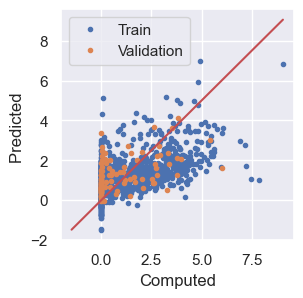

Epoch: 1, Train MAE: 1.2911, Val MAE: 1.2105
Epoch: 2, Train MAE: 1.2650, Val MAE: 1.2122
Epoch: 3, Train MAE: 1.2764, Val MAE: 1.1997
Epoch: 4, Train MAE: 1.2607, Val MAE: 1.1965
Epoch: 5, Train MAE: 1.2595, Val MAE: 1.2222
Epoch: 6, Train MAE: 1.2686, Val MAE: 1.1928
Epoch: 7, Train MAE: 1.2560, Val MAE: 1.2123
Epoch: 8, Train MAE: 1.2818, Val MAE: 1.2077
Epoch: 9, Train MAE: 1.2586, Val MAE: 1.2036
Epoch: 10, Train MAE: 1.2512, Val MAE: 1.1992


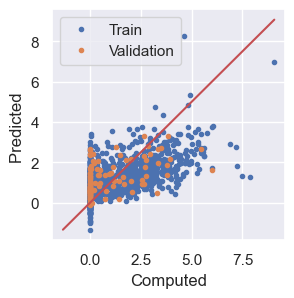

Epoch: 11, Train MAE: 1.2570, Val MAE: 1.1974
Epoch: 12, Train MAE: 1.2509, Val MAE: 1.1951
Epoch: 13, Train MAE: 1.2648, Val MAE: 1.2077
Epoch: 14, Train MAE: 1.2517, Val MAE: 1.1869
Epoch: 15, Train MAE: 1.2473, Val MAE: 1.1854
Epoch: 16, Train MAE: 1.2483, Val MAE: 1.2016
Epoch: 17, Train MAE: 1.2502, Val MAE: 1.1904
Epoch: 18, Train MAE: 1.2474, Val MAE: 1.1977
Epoch: 19, Train MAE: 1.2322, Val MAE: 1.1938
Epoch: 20, Train MAE: 1.2390, Val MAE: 1.1954


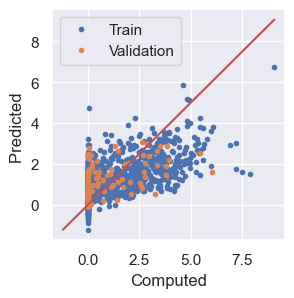

Epoch: 21, Train MAE: 1.2490, Val MAE: 1.1891
Epoch: 22, Train MAE: 1.2531, Val MAE: 1.1952
Epoch: 23, Train MAE: 1.2316, Val MAE: 1.1973
Epoch: 24, Train MAE: 1.2383, Val MAE: 1.1913
Epoch: 25, Train MAE: 1.2205, Val MAE: 1.1865
Epoch: 26, Train MAE: 1.2340, Val MAE: 1.2003
Epoch: 27, Train MAE: 1.2378, Val MAE: 1.1862
Epoch: 28, Train MAE: 1.2341, Val MAE: 1.1925
Epoch: 29, Train MAE: 1.2326, Val MAE: 1.1950
Epoch: 30, Train MAE: 1.2243, Val MAE: 1.1817


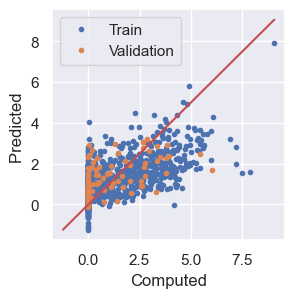

Epoch: 31, Train MAE: 1.2148, Val MAE: 1.1952
Epoch: 32, Train MAE: 1.2263, Val MAE: 1.1810
Epoch: 33, Train MAE: 1.2268, Val MAE: 1.1857
Epoch: 34, Train MAE: 1.2136, Val MAE: 1.2032
Epoch: 35, Train MAE: 1.2243, Val MAE: 1.1774
Epoch: 36, Train MAE: 1.2179, Val MAE: 1.1857
Epoch: 37, Train MAE: 1.2187, Val MAE: 1.1849
Epoch: 38, Train MAE: 1.2205, Val MAE: 1.1714
Epoch: 39, Train MAE: 1.2101, Val MAE: 1.1935
Epoch: 40, Train MAE: 1.2067, Val MAE: 1.1791


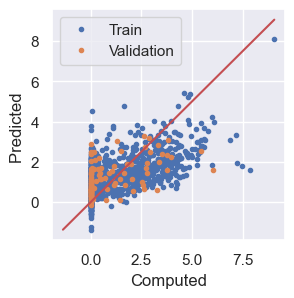

Epoch: 41, Train MAE: 1.2268, Val MAE: 1.1778
Epoch: 42, Train MAE: 1.2125, Val MAE: 1.1830
Epoch: 43, Train MAE: 1.2225, Val MAE: 1.1806
Epoch: 44, Train MAE: 1.2072, Val MAE: 1.1824
Epoch: 45, Train MAE: 1.1958, Val MAE: 1.1763
Epoch: 46, Train MAE: 1.1919, Val MAE: 1.1882
Epoch: 47, Train MAE: 1.2039, Val MAE: 1.1681
Epoch: 48, Train MAE: 1.1960, Val MAE: 1.1779
Epoch: 49, Train MAE: 1.2077, Val MAE: 1.1758
Epoch: 50, Train MAE: 1.1962, Val MAE: 1.1710


In [20]:
# Train the model
train_losses = []
val_losses   = []
for epoch in np.arange(0, n_epochs):
    train_loss, train_predictions, train_ground_truths = clm.train(model, criterion, train_loader,
                                                                   target_factor,
                                                                   standardized_parameters['target_mean'],
                                                                   optimizer)
    val_loss,   val_predictions,   val_ground_truths   =  clm.test(model, criterion, val_loader,
                                                                   target_factor,
                                                                   standardized_parameters['target_mean'])

    # Convert to original units
    train_loss = np.sum(np.sqrt(train_loss) * target_factor)
    val_loss   = np.sum(np.sqrt(val_loss)   * target_factor)

    if epoch%10 == 0:
        cld.parity_plot(train=np.array([train_ground_truths, train_predictions]),
                        validation=np.array([val_ground_truths, val_predictions]))
    
    # Append losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Check early stopping criteria
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print('Early stopping')
        break

    print(f'Epoch: {epoch+1}, Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}')

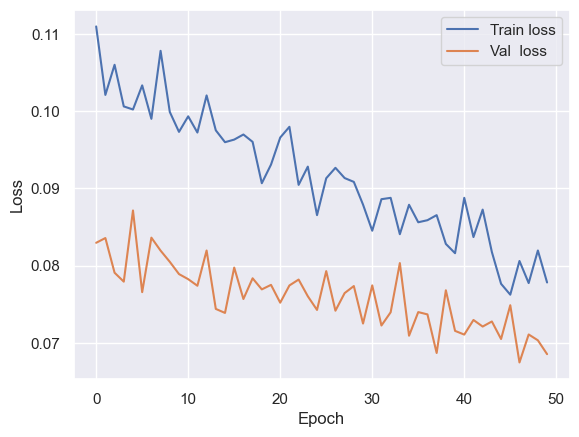

In [21]:
cld.losses_plot(train_losses=train_losses,
                val_losses=val_losses,
                to_log=True)

# Check test data

In [22]:
model = clm.load_model(n_node_features, dropout, device, model_name=files_names['model'], mode='eval')
model

DataParallel(
  (module): GCNN(
    (conv1): GraphConv(4, 512)
    (conv2): GraphConv(512, 512)
    (linconv1): Linear(in_features=512, out_features=64, bias=True)
    (linconv2): Linear(in_features=64, out_features=16, bias=True)
    (lin): Linear(in_features=16, out_features=1, bias=True)
  )
)

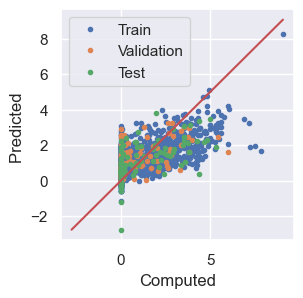

Train MAE: 1.1683, Val MAE: 1.1681, Test MAE: 1.1801


In [23]:
train_loss, train_predictions, train_ground_truths = clm.test(model, criterion, train_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])
val_loss,   val_predictions,   val_ground_truths   = clm.test(model, criterion, val_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])
test_loss,  test_predictions,  test_ground_truths  = clm.test(model, criterion, test_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])

# Pass to energy units (same as initial Fv)
train_loss = np.sum(np.sqrt(train_loss) * target_factor)
val_loss   = np.sum(np.sqrt(val_loss)   * target_factor)
test_loss  = np.sum(np.sqrt(test_loss)  * target_factor)

cld.parity_plot(train=np.array([train_ground_truths, train_predictions]),
                validation=np.array([val_ground_truths, val_predictions]),
                test=np.array([test_ground_truths, test_predictions]),
                save_to=f'{timestamped_folder}/GCNN-training.pdf')

print(f'Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}, Test MAE: {test_loss:.4f}')

In [24]:
import json

# Save detailed results to the timestamped model folder
results_data = {
    'timestamp': timestamp,
    'model_parameters': model_parameters,
    'training_history': {
        'train_losses': [float(loss) for loss in train_losses],
        'val_losses': [float(loss) for loss in val_losses],
        'epochs_completed': len(train_losses)
    },
    'final_metrics': {
        'train_mae': float(train_loss),
        'val_mae': float(val_loss),
        'test_mae': float(test_loss)
    },
    'predictions': {
        'train': {
            'predicted': train_predictions.tolist(),
            'actual': train_ground_truths.tolist()
        },
        'validation': {
            'predicted': val_predictions.tolist(),
            'actual': val_ground_truths.tolist()
        },
        'test': {
            'predicted': test_predictions.tolist(),
            'actual': test_ground_truths.tolist()
        }
    }
}

results_file = f'{timestamped_folder}/model_results_{timestamp}.json'
with open(results_file, 'w') as f:
    json.dump(results_data, f, indent=4)

print(f'Model results saved to: {results_file}')

Model results saved to: models/free-energies/results_20260409_154940/model_results_20260409_154940.json


In [18]:
import importlib
importlib.reload(cld)

<module 'libraries.dataset' from 'c:\\Users\\mateu\\Desktop\\gnn-material-science\\gnn-material-science\\gnn-material-science\\libraries\\dataset.py'>

Cargando resultados desde: models/free-energies/results_20260409_154940/model_results_20260409_154940.json

=== Curva de Aprendizaje (Loss) ===


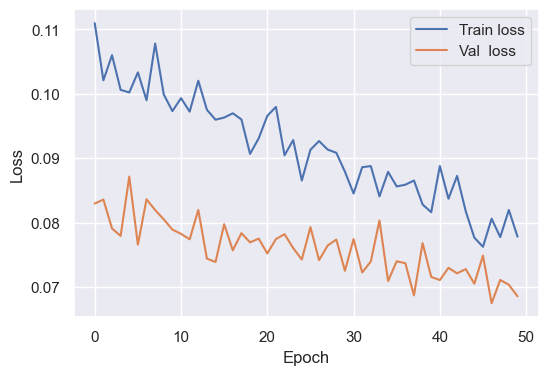


=== Predicción vs Realidad (Conjunto de Test) ===


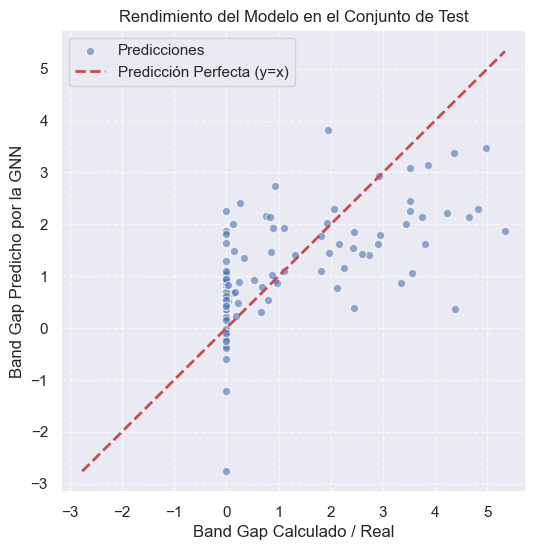


=== Métricas Finales (MAE) ===
Train MAE: 1.1683
Val MAE:   1.1681
Test MAE:  1.1801


In [29]:
import matplotlib.pyplot as plt

# 1. Definir la ruta del archivo (o usar la variable results_file si ya está en memoria)
results_file = f'{timestamped_folder}/model_results_{timestamp}.json'
print(f"Cargando resultados desde: {results_file}")

with open(results_file, 'r') as f:
    results_data = json.load(f)

# Extraer datos
train_losses = results_data['training_history']['train_losses']
val_losses = results_data['training_history']['val_losses']
predicted = results_data['predictions']['test']['predicted']
actual = results_data['predictions']['test']['actual']

# ==========================================
# 2. Visualización de la Curva de Aprendizaje
# ==========================================
print("\n=== Curva de Aprendizaje (Loss) ===")
# Esta función sí sabemos que existe y se llama así
plt.figure(figsize=(6, 4))
cld.losses_plot(train_losses, val_losses, to_log=True)
plt.show() # Forzamos a que se dibuje aquí para que no se mezcle con el siguiente

# ==========================================
# 3. Visualización de Predicción vs Realidad (Directo con Matplotlib)
# ==========================================
print("\n=== Predicción vs Realidad (Conjunto de Test) ===")
plt.figure(figsize=(6, 6))

# Dibujar los puntos
plt.scatter(actual, predicted, alpha=0.6, edgecolors='w', label='Predicciones')

# Dibujar la línea de predicción perfecta (y = x)
min_val = min(min(actual), min(predicted))
max_val = max(max(actual), max(predicted))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción Perfecta (y=x)')

# Formato del gráfico
plt.xlabel('Band Gap Calculado / Real')
plt.ylabel('Band Gap Predicho por la GNN')
plt.title('Rendimiento del Modelo en el Conjunto de Test')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# 4. Métricas
# ==========================================
print("\n=== Métricas Finales (MAE) ===")
print(f"Train MAE: {results_data['final_metrics']['train_mae']:.4f}")
print(f"Val MAE:   {results_data['final_metrics']['val_mae']:.4f}")
print(f"Test MAE:  {results_data['final_metrics']['test_mae']:.4f}")